# Experimento 04 (baseline/Ga+Ju)

Investigar a existência de agrupamentos naturais nos dados biomecânicos da marcha do subconjunto Ga e Ju utilizando K-Means sem redução dimensional.

# 1. Importando as bibliotecas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from google.colab import drive

# 2. Montando o Google Drive

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Carregando o Dataset Baseline

In [3]:
BASE_PATH = Path('/content/drive/MyDrive/results')

ga_file = BASE_PATH / 'ga_baseline_features.csv'
ju_file = BASE_PATH / 'ju_baseline_features.csv'

ga_df = pd.read_csv(ga_file)
ju_df = pd.read_csv(ju_file)

In [4]:
combined_df = pd.concat(
    [ga_df, ju_df],
    ignore_index=True
)

In [5]:
combined_df.shape

(242, 12)

In [6]:
combined_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
0,Ga,GaPt24_10,473.238435,502.094442,411.342104,422.206326,0.869207,0.840890,-28.856007,28.856007,1188.55,1210.77
1,Ga,GaCo09_02,470.210635,423.825689,409.763042,374.653720,0.871446,0.883981,46.384946,46.384946,1151.26,983.62
2,Ga,GaPt14_10,540.243175,425.180815,461.761851,389.215544,0.854730,0.915412,115.062360,115.062360,1276.00,1092.96
3,Ga,GaPt08_02,391.887131,419.585864,340.767717,370.100560,0.869556,0.882062,-27.698733,27.698733,904.86,927.74
4,Ga,GaPt28_10,591.748944,593.337949,488.596962,482.026601,0.825683,0.812398,-1.589005,1.589005,1324.84,1342.77


In [7]:
combined_df.info()
combined_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataset          242 non-null    object 
 1   patient_id       242 non-null    object 
 2   mean_total_L     242 non-null    float64
 3   mean_total_R     242 non-null    float64
 4   std_total_L      242 non-null    float64
 5   std_total_R      242 non-null    float64
 6   cv_total_L       242 non-null    float64
 7   cv_total_R       242 non-null    float64
 8   assimetria_mean  242 non-null    float64
 9   assimetria_abs   242 non-null    float64
 10  peak_force_L     242 non-null    float64
 11  peak_force_R     242 non-null    float64
dtypes: float64(10), object(2)
memory usage: 22.8+ KB


,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000
mean,455.544255,455.307382,391.888650,393.102407,0.861987,0.864786,0.236874,28.693011,1074.750000,1067.838182
std,76.981658,70.565132,64.409574,59.232029,0.041904,0.036232,38.945229,26.269415,178.346627,166.761694
min,257.118875,251.897876,226.298854,224.369987,0.638924,0.733060,-104.968020,0.159885,679.360000,662.200000
25%,401.873861,417.984249,350.812519,358.377153,0.840492,0.845527,-20.342063,9.443509,949.712500,959.722500
50%,458.965213,456.608315,387.612824,394.648751,0.863282,0.866538,0.609947,20.413910,1046.210000,1052.315000
75%,499.209054,500.247280,436.208871,434.935940,0.881520,0.883242,20.491964,41.217376,1207.992500,1182.527500
max,687.630032,702.366501,612.168131,634.996815,1.178253,1.163285,122.906652,122.906652,1816.540000,1866.590000


# 4. Defininção das features

Removendo colunas não utilizadas no clustering

In [8]:
feature_cols = [
    'mean_total_L',
    'mean_total_R',

    'std_total_L',
    'std_total_R',

    'cv_total_L',
    'cv_total_R',

    'assimetria_mean',
    'assimetria_abs',

    'peak_force_L',
    'peak_force_R'
]

X = combined_df[feature_cols]

# 5. Normalização dos dados

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 6. Escolha do número de clusters

## Elbow Method

In [10]:
inertia = []

k_values = range(2, 7)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

Visualizando o Elbow Method

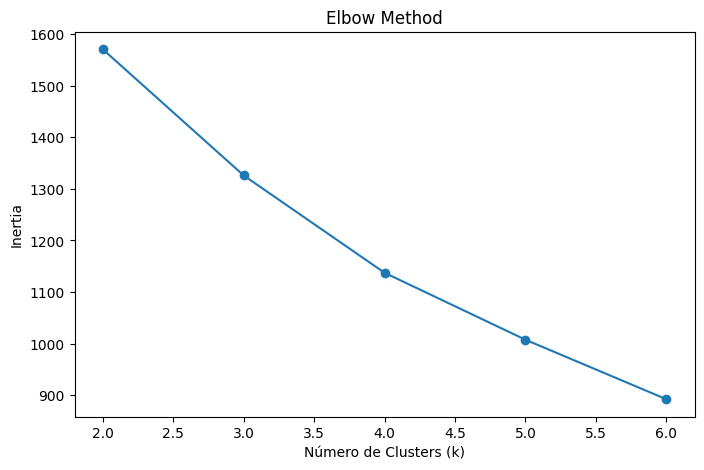

In [11]:
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inertia')

plt.show()

# 7. Avaliação com Silhouette Score

In [12]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f'k={k} | Silhouette Score: {score:.4f}')

k=2 | Silhouette Score: 0.3245
k=3 | Silhouette Score: 0.2429
k=4 | Silhouette Score: 0.2789
k=5 | Silhouette Score: 0.2829
k=6 | Silhouette Score: 0.2906


Vizualização com o Silhouette Score

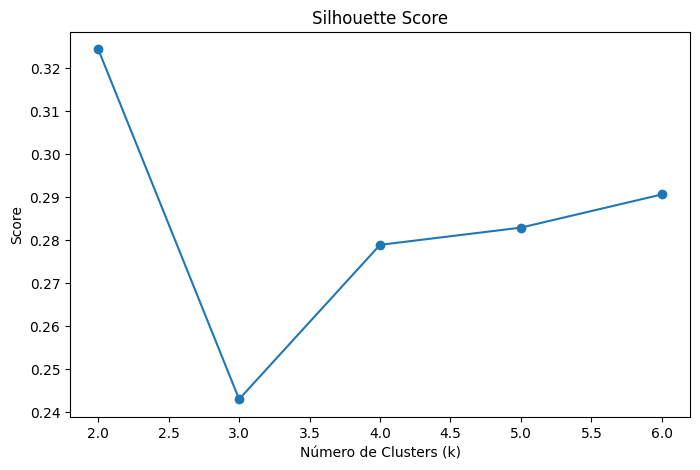

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Score')

plt.show()

# 8. Treinamento final com o K-Means

In [14]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

Adicionando clusters ao dataframe

In [15]:
combined_df['cluster'] = clusters

combined_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R,cluster
0,Ga,GaPt24_10,473.238435,502.094442,411.342104,422.206326,0.869207,0.840890,-28.856007,28.856007,1188.55,1210.77,1
1,Ga,GaCo09_02,470.210635,423.825689,409.763042,374.653720,0.871446,0.883981,46.384946,46.384946,1151.26,983.62,0
2,Ga,GaPt14_10,540.243175,425.180815,461.761851,389.215544,0.854730,0.915412,115.062360,115.062360,1276.00,1092.96,1
3,Ga,GaPt08_02,391.887131,419.585864,340.767717,370.100560,0.869556,0.882062,-27.698733,27.698733,904.86,927.74,0
4,Ga,GaPt28_10,591.748944,593.337949,488.596962,482.026601,0.825683,0.812398,-1.589005,1.589005,1324.84,1342.77,1


# 9. Métricas Internas

In [16]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)

davies = davies_bouldin_score(
    X_scaled,
    clusters
)

calinski = calinski_harabasz_score(
    X_scaled,
    clusters
)

print(f'Silhouette Score: {silhouette:.4f}')
print(f'Davies-Bouldin Index: {davies:.4f}')
print(f'Calinski-Harabasz Score: {calinski:.4f}')

Silhouette Score: 0.3245
Davies-Bouldin Index: 1.1879
Calinski-Harabasz Score: 129.7293


# 10. Visualização dos Clusters

PCA somente usado para visualização

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

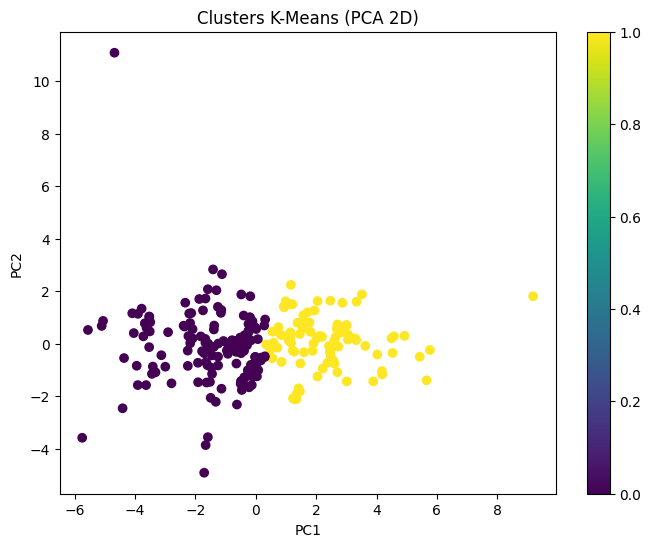

In [18]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title('Clusters K-Means (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.colorbar(scatter)

plt.show()

# 11. HeatMap dos centroídes

In [19]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols
)

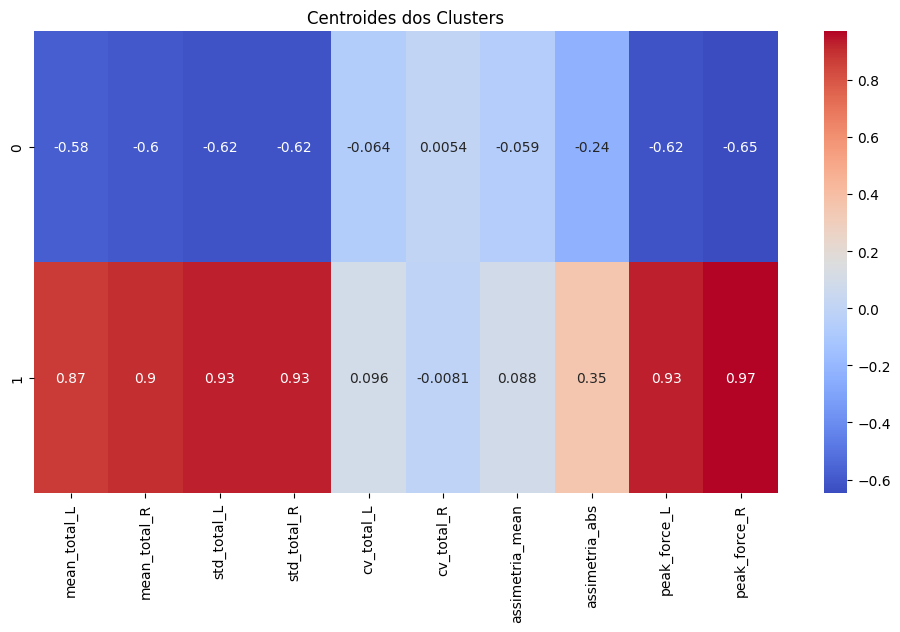

In [20]:
plt.figure(figsize=(12,6))

sns.heatmap(
    centroids,
    annot=True,
    cmap='coolwarm'
)

plt.title('Centroides dos Clusters')

plt.show()

# 12. Distribuição dos Clusters

In [21]:
combined_df['cluster'].value_counts()

,count
cluster,
0,145
1,97


# 13. Composição dos clusters por dataset

In [22]:
combined_df.groupby('cluster')['dataset'].value_counts()

cluster  dataset
0        Ju         75
         Ga         70
1        Ju         54
         Ga         43
Name: count, dtype: int64

# 14. Média das features por cluster e dataset

In [23]:
combined_df.groupby(
    ['cluster', 'dataset']
)[feature_cols].mean()

mean_total_L  mean_total_R  std_total_L  std_total_R  \
cluster dataset                                                         
0       Ga         406.351757    410.993146   347.004802   355.108122   
        Ju         414.915429    414.532003   356.529986   357.594345   
1       Ga         537.102349    521.855766   461.055481   448.907072   
        Ju         510.796827    516.392001   444.103379   447.233961   

                 cv_total_L  cv_total_R  assimetria_mean  assimetria_abs  \
cluster dataset                                                            
0       Ga         0.857234    0.866041        -4.641389       25.914392   
        Ju         0.861223    0.863992         0.383425       19.286594   
1       Ga         0.859637    0.861526        15.246583       36.164575   
        Ju         0.871081    0.866858        -5.595174       39.409817   

                 peak_force_L  peak_force_R  
cluster dataset                              
0       Ga         949.758857    960.350286  
        Ju         977.143200    959.593067  
1       Ga        1258.297674   1242.460233  
        Ju        1226.182222   1218.463889